# 05 — EDA

**Inputs:** `aves_train.parquet`, `mamiferos_train.parquet`  

**Secciones:**
1. Carga y overview
2. Distribución del target (imbalance)
3. Correlación entre features
4. Distribuciones por grupo (threatened vs not)
5. Correlación con el target
6. Outliers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
DATA = Path('../data/processed')

aves = pd.read_parquet(DATA / 'aves_train.parquet', engine='fastparquet')
mam  = pd.read_parquet(DATA / 'mamiferos_train.parquet', engine='fastparquet')

# Columnas de features (excluir metadata)
META = ['species', 'iucn_categoria', 'threatened']
feat_aves = [c for c in aves.columns if c not in META]
feat_mam  = [c for c in mam.columns  if c not in META]

print(f'Aves:     {aves.shape}  — {len(feat_aves)} features')
print(f'Mammalia: {mam.shape}   — {len(feat_mam)} features')

Aves:     (1313, 67)  — 64 features
Mammalia: (189, 32)   — 29 features


## 1. Overview

In [2]:
for name, df in [('AVES', aves), ('MAMÍFEROS', mam)]:
    print(f'=== {name} ===')
    print(df[feat_aves if name == 'AVES' else feat_mam].describe().round(3).T[['mean','std','min','max']])
    print()

=== AVES ===
                                   mean       std     min        max
n_occ                           939.309  1701.121   1.000  15175.000
bio1                             21.129     5.248   4.246     27.067
bio4                            161.579    50.057  57.957    349.482
bio7                             17.651     2.517  14.137     26.700
bio12                          1335.349   432.132  73.000   3951.000
...                                 ...       ...     ...        ...
Primary.Lifestyle_Aerial          0.094     0.293   0.000      1.000
Primary.Lifestyle_Aquatic         0.024     0.152   0.000      1.000
Primary.Lifestyle_Generalist      0.055     0.228   0.000      1.000
Primary.Lifestyle_Insessorial     0.612     0.487   0.000      1.000
Primary.Lifestyle_Terrestrial     0.215     0.411   0.000      1.000

[64 rows x 4 columns]

=== MAMÍFEROS ===
                               mean          std        min           max
n_occ                        18.550       4

## 2. Distribución del target (imbalance)

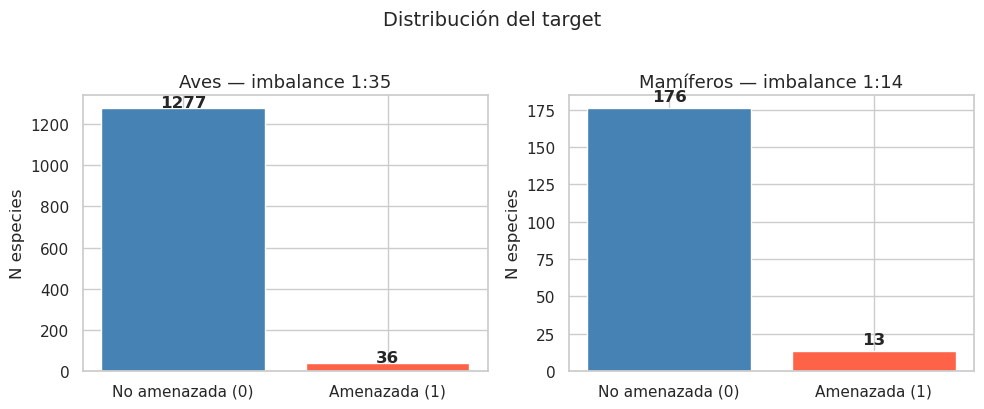

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, df) in zip(axes, [('Aves', aves), ('Mamíferos', mam)]):
    counts = df['threatened'].value_counts().sort_index()
    bars = ax.bar(['No amenazada (0)', 'Amenazada (1)'], counts.values,
                  color=['steelblue', 'tomato'], edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontweight='bold')
    ratio = counts[0] / counts[1]
    ax.set_title(f'{name} — imbalance 1:{ratio:.0f}', fontsize=13)
    ax.set_ylabel('N especies')

plt.suptitle('Distribución del target', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_desbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlación entre features

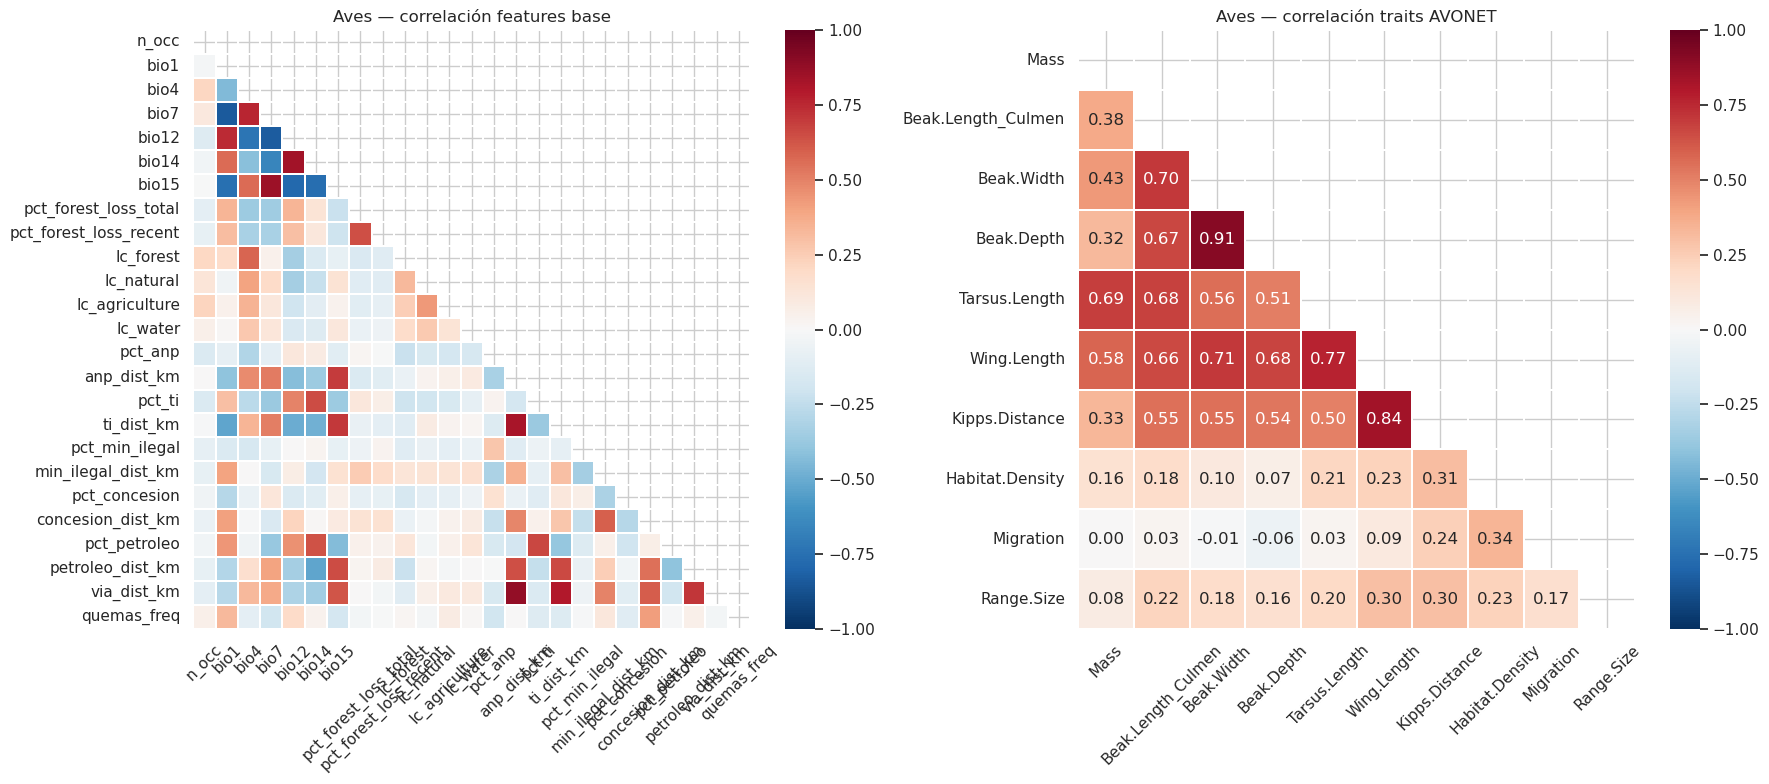

In [4]:
# Solo features numéricas base (sin OHE) para el heatmap de aves
BASE_NUM = [
    'n_occ', 'bio1', 'bio4', 'bio7', 'bio12', 'bio14', 'bio15',
    'pct_forest_loss_total', 'pct_forest_loss_recent',
    'lc_forest', 'lc_natural', 'lc_agriculture', 'lc_water',
    'pct_anp', 'anp_dist_km', 'pct_ti', 'ti_dist_km',
    'pct_min_ilegal', 'min_ilegal_dist_km', 'pct_concesion', 'concesion_dist_km',
    'pct_petroleo', 'petroleo_dist_km', 'via_dist_km', 'quemas_freq',
]
AVONET_NUM = [
    'Mass', 'Beak.Length_Culmen', 'Beak.Width', 'Beak.Depth',
    'Tarsus.Length', 'Wing.Length', 'Kipps.Distance',
    'Habitat.Density', 'Migration', 'Range.Size',
]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Aves — features base numéricas
corr_aves = aves[BASE_NUM].corr()
mask = np.triu(np.ones_like(corr_aves, dtype=bool))
sns.heatmap(corr_aves, mask=mask, ax=axes[0], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3)
axes[0].set_title('Aves — correlación features base', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Aves — traits AVONET
corr_avonet = aves[AVONET_NUM].corr()
mask2 = np.triu(np.ones_like(corr_avonet, dtype=bool))
sns.heatmap(corr_avonet, mask=mask2, ax=axes[1], cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', linewidths=0.3)
axes[1].set_title('Aves — correlación traits AVONET', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_correlaciones_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Pares con correlación muy alta (|r| > 0.85)
print('=== Correlaciones altas |r| > 0.85 — AVES (base) ===')
corr_vals = corr_aves.abs().unstack()
high = corr_vals[(corr_vals > 0.85) & (corr_vals < 1.0)].drop_duplicates().sort_values(ascending=False)
print(high.to_string() if len(high) > 0 else 'Ninguna')

print()
print('=== Correlaciones altas |r| > 0.85 — AVONET ===')
corr_av = corr_avonet.abs().unstack()
high_av = corr_av[(corr_av > 0.85) & (corr_av < 1.0)].drop_duplicates().sort_values(ascending=False)
print(high_av.to_string() if len(high_av) > 0 else 'Ninguna')

=== Correlaciones altas |r| > 0.85 — AVES (base) ===
anp_dist_km  via_dist_km    0.882145
bio7         bio15          0.857379

=== Correlaciones altas |r| > 0.85 — AVONET ===
Beak.Width  Beak.Depth    0.906891


## 4. Distribuciones por grupo — features clave

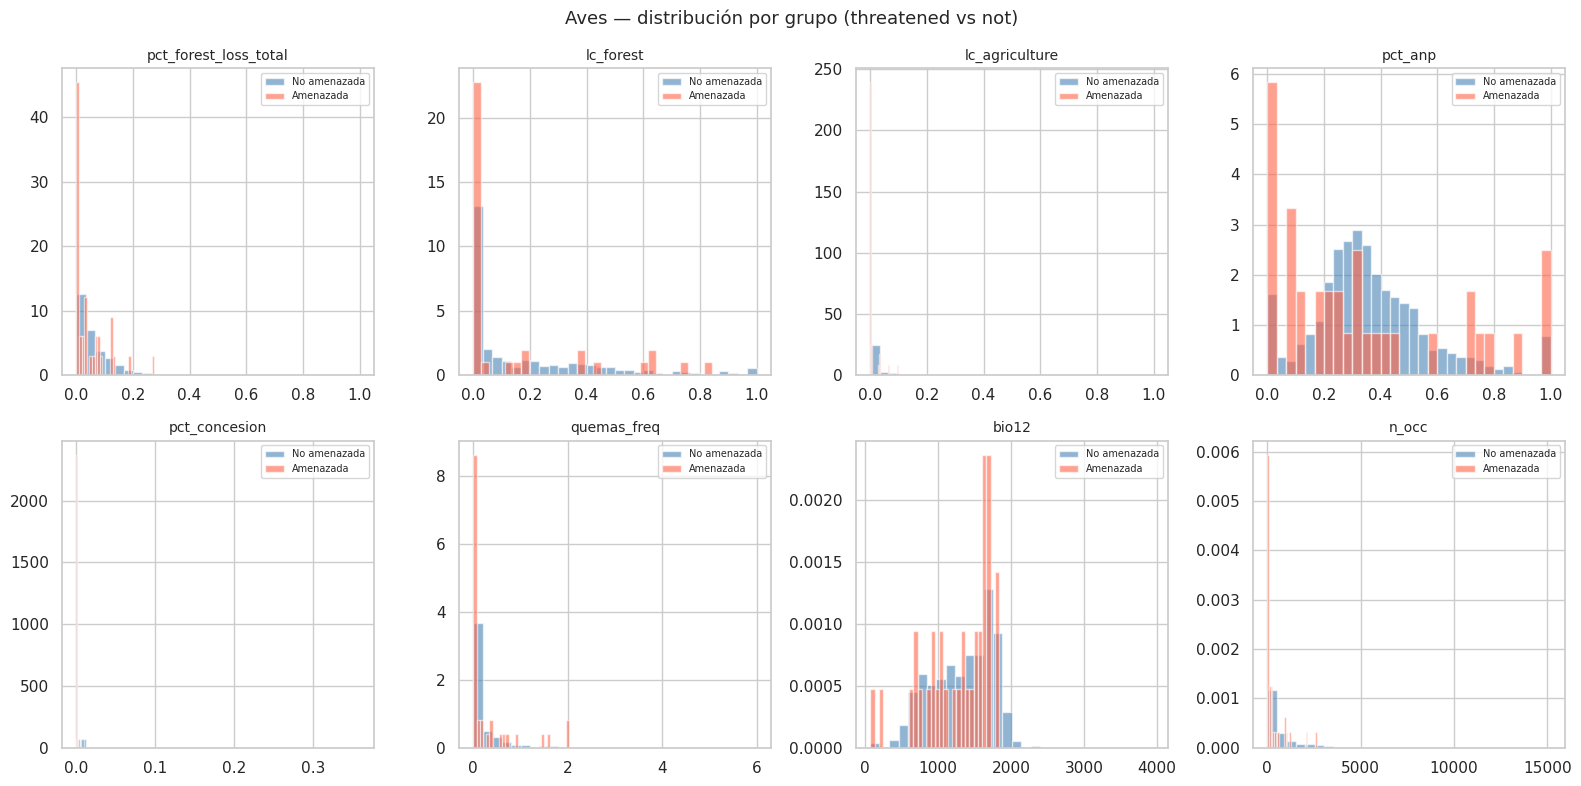

In [6]:
KEY_FEATURES = [
    'pct_forest_loss_total', 'lc_forest', 'lc_agriculture',
    'pct_anp', 'pct_concesion', 'quemas_freq',
    'bio12', 'n_occ',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_FEATURES):
    for val, label, color in [(0, 'No amenazada', 'steelblue'), (1, 'Amenazada', 'tomato')]:
        data = aves[aves['threatened'] == val][feat].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

plt.suptitle('Aves — distribución por grupo (threatened vs not)', fontsize=13)
plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_dist_aves.png', dpi=150, bbox_inches='tight')
plt.show()

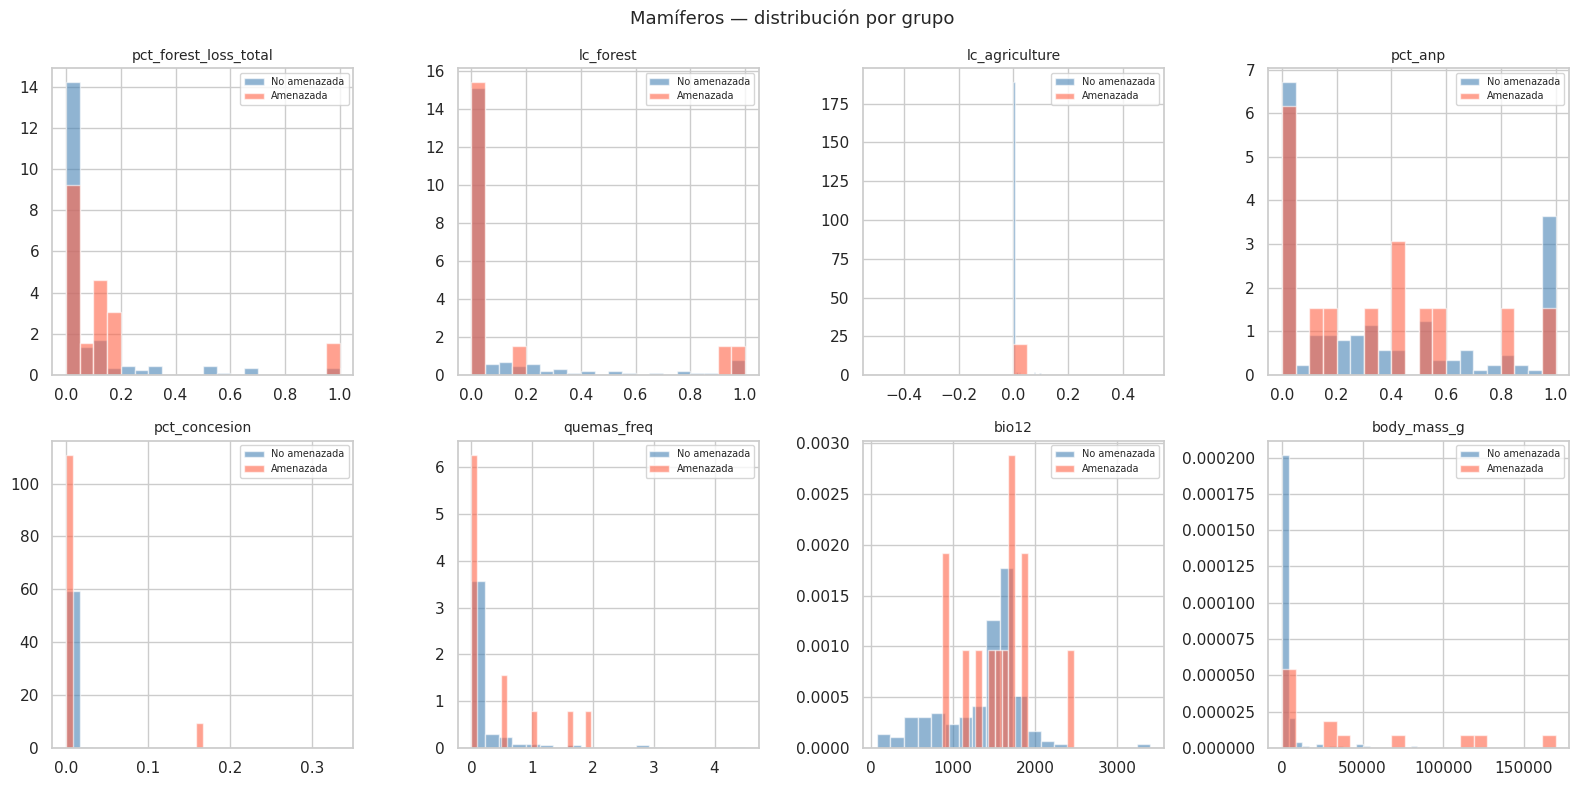

In [7]:
# Mismo plot para mamíferos
KEY_MAM = [
    'pct_forest_loss_total', 'lc_forest', 'lc_agriculture',
    'pct_anp', 'pct_concesion', 'quemas_freq',
    'bio12', 'body_mass_g',
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, feat in zip(axes, KEY_MAM):
    for val, label, color in [(0, 'No amenazada', 'steelblue'), (1, 'Amenazada', 'tomato')]:
        data = mam[mam['threatened'] == val][feat].dropna()
        ax.hist(data, bins=20, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

plt.suptitle('Mamíferos — distribución por grupo', fontsize=13)
plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_dist_mamiferos.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlación con el target (point-biserial)

In [8]:
from scipy import stats

def correlacion_con_target(df, feat_cols, target='threatened'):
    """Correlación point-biserial de cada feature numérica con el target binario."""
    resultados = {}
    num_cols = df[feat_cols].select_dtypes(include='number').columns
    for col in num_cols:
        r, p = stats.pointbiserialr(df[target], df[col])
        resultados[col] = {'r': r, 'p': p}
    res = pd.DataFrame(resultados).T.sort_values('r', key=abs, ascending=False)
    res['significativa'] = res['p'] < 0.05
    return res

corr_target_aves = correlacion_con_target(aves, feat_aves)
corr_target_mam  = correlacion_con_target(mam, feat_mam)

print('=== Top 20 features por correlación con threatened — AVES ===')
print(corr_target_aves.head(20).round(4).to_string())

=== Top 20 features por correlación con threatened — AVES ===
                                     r       p  significativa
Beak.Depth                      0.1990  0.0000           True
Wing.Length                     0.1621  0.0000           True
Kipps.Distance                  0.1600  0.0000           True
Beak.Width                      0.1334  0.0000           True
concesion_dist_km               0.1203  0.0000           True
via_dist_km                     0.1183  0.0000           True
Tarsus.Length                   0.1169  0.0000           True
Mass                            0.1158  0.0000           True
petroleo_dist_km                0.1019  0.0002           True
anp_dist_km                     0.0991  0.0003           True
Primary.Lifestyle_Terrestrial   0.0939  0.0007           True
Beak.Length_Culmen              0.0867  0.0017           True
Trophic.Niche_Invertivore      -0.0838  0.0024           True
Range.Size                     -0.0779  0.0047           True
Trophic.

In [9]:
print('=== Correlación con threatened — MAMÍFEROS ===')
print(corr_target_mam.round(4).to_string())

=== Correlación con threatened — MAMÍFEROS ===
                             r       p  significativa
body_mass_g             0.5245  0.0000           True
pct_forest_loss_recent  0.1889  0.0092           True
bio14                   0.1564  0.0316           True
bio15                  -0.1219  0.0947          False
petroleo_dist_km       -0.1131  0.1213          False
quemas_freq             0.1052  0.1497          False
pct_concesion           0.1011  0.1664          False
activity_cycle          0.0933  0.2015          False
bio12                   0.0930  0.2030          False
concesion_dist_km      -0.0829  0.2565          False
pct_forest_loss_total   0.0757  0.3003          False
bio7                   -0.0656  0.3701          False
lc_forest               0.0611  0.4036          False
pct_ti                  0.0587  0.4223          False
pct_petroleo            0.0581  0.4268          False
min_ilegal_dist_km     -0.0546  0.4554          False
lc_agriculture         -0.0469  0.5

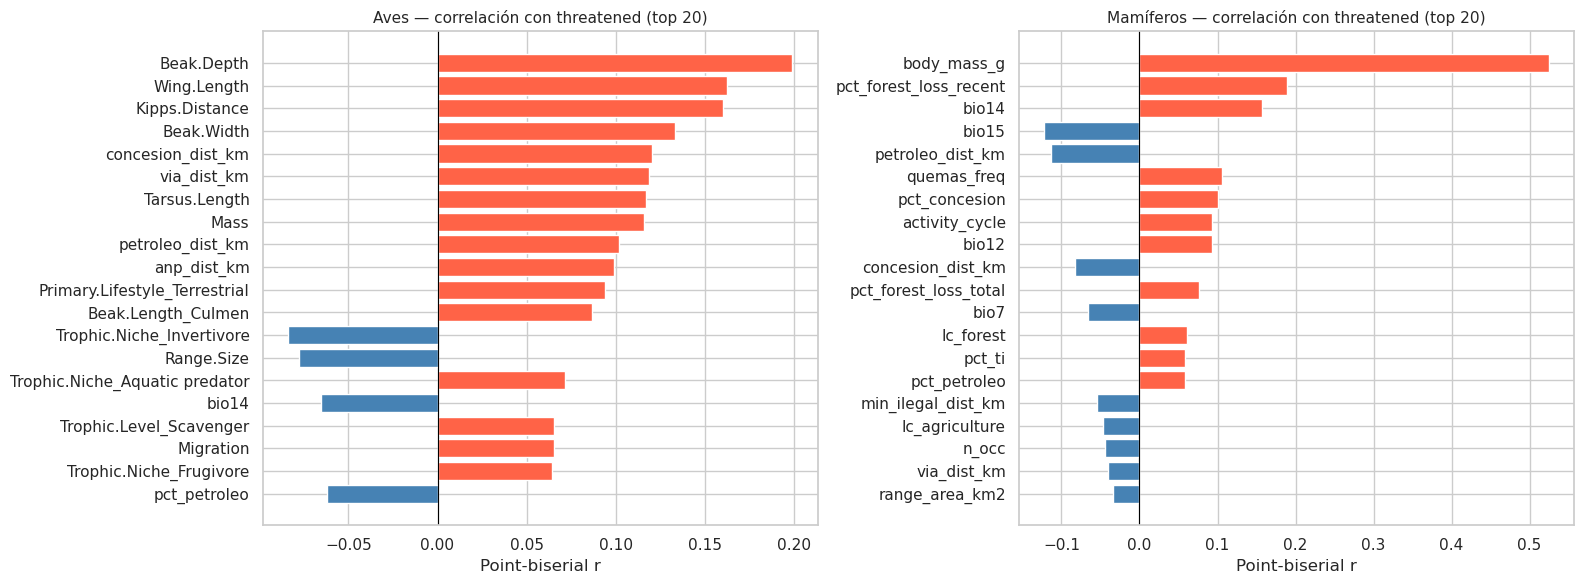

In [10]:
# Visualización — top features por |r|
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, corr_df) in zip(axes, [('Aves', corr_target_aves), ('Mamíferos', corr_target_mam)]):
    top = corr_df.head(20).copy()
    colors = ['tomato' if r > 0 else 'steelblue' for r in top['r']]
    ax.barh(top.index[::-1], top['r'].values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} — correlación con threatened (top 20)', fontsize=11)
    ax.set_xlabel('Point-biserial r')

plt.tight_layout()
plt.savefig('/home/max1/ml/proy_sup/informe/img/img_corr_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Outliers

In [11]:
# Detección por IQR — contar outliers por feature
def contar_outliers(df, feat_cols):
    num_cols = df[feat_cols].select_dtypes(include='number').columns
    resultados = {}
    for col in num_cols:
        Q1, Q3 = df[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        n_out = ((df[col] < Q1 - 3*IQR) | (df[col] > Q3 + 3*IQR)).sum()
        if n_out > 0:
            resultados[col] = n_out
    return pd.Series(resultados).sort_values(ascending=False)

print('=== Outliers severos (IQR x3) — AVES ===')
out_aves = contar_outliers(aves, feat_aves)
print(out_aves.to_string() if len(out_aves) > 0 else 'Ninguno')

print()
print('=== Outliers severos (IQR x3) — MAMÍFEROS ===')
out_mam = contar_outliers(mam, feat_mam)
print(out_mam.to_string() if len(out_mam) > 0 else 'Ninguno')

=== Outliers severos (IQR x3) — AVES ===
Primary.Lifestyle_Terrestrial          282
Migration                              251
lc_water                               228
Habitat_Shrubland                      175
Trophic.Level_Omnivore                 167
Trophic.Niche_Omnivore                 163
Mass                                   159
lc_agriculture                         143
Trophic.Niche_Frugivore                138
pct_concesion                          129
Primary.Lifestyle_Aerial               124
Habitat_Grassland                      121
Habitat_Wetland                        108
pct_ti                                 103
pct_min_ilegal                         103
Trophic.Niche_Aquatic predator          83
lc_natural                              80
quemas_freq                             76
Trophic.Niche_Granivore                 74
Tarsus.Length                           73
Primary.Lifestyle_Generalist            72
petroleo_dist_km                        72
Trophic.Niche

In [12]:
# Nota: no eliminamos outliers — los modelos de árbol son robustos a ellos.
# Para LR y SVM se escalarán las features en el notebook de modelos.
print('Los outliers se gestionarán en el notebook de modelos:')
print('  - Tree-based (RF, GB): robustos, sin acción necesaria')
print('  - LR y SVM: se escalarán con StandardScaler en el pipeline')

Los outliers se gestionarán en el notebook de modelos:
  - Tree-based (RF, GB): robustos, sin acción necesaria
  - LR y SVM: se escalarán con StandardScaler en el pipeline
